# 潜扩散模型 (LDM) — COCO 2017 文本生成图像

**架构**：VAE + CLIP ViT-L/14 + 条件 U-Net (DDPM)  
**数据集**：MS COCO 2017 Images + Captions  
**分辨率**：256×256 RGB -> 32×32×4 Latent

---

## 整体流程
```
阶段一：预处理
  COCO 图片  --> VAE Encode --> latent.pt
  COCO Caption --> CLIP Encode --> text_emb.pt

阶段二：训练
  latent.pt + text_emb.pt --> UNet2DConditionModel + DDPMScheduler --> 权重保存

阶段三：推理
  文本 prompt --> CLIP --> UNet 去噪循环 (CFG) --> VAE Decode --> 256×256 图像
```

## 第一部分：数据预处理
将 COCO 图片经 VAE 编码为 Latent，将 Caption 经 CLIP 编码为 Text Embeddings，保存到磁盘。  
训练时 DataLoader 直接读取预处理好的 `.pt` 文件，无需再次加载 VAE/CLIP，极大提升速度。

In [ ]:
#  空间占用估算

# 数据规模
TRAIN_IMGS = 118_287   # COCO train2017 实测图片数
VAL_IMGS   = 5_000     # COCO val2017

# 单文件实际数据字节数（float16）
latent_bytes  = 4 * 32 * 32 * 2          #  8,192 B  =  8.0 KB
text_bytes    = 77 * 768 * 2             # 118,272 B  = 115.5 KB

NPY_HEADER    = 128                      # .npy 固定头部大小（字节）
PT_OVERHEAD   = 120 * 1024              # .pt  pickle 元数据实测开销（约 120 KB）

latent_npy_kb = (latent_bytes + NPY_HEADER) / 1024
text_npy_kb   = (text_bytes   + NPY_HEADER) / 1024
latent_pt_kb  = 129.5    # 实测值
text_pt_kb    = 1806.0   # 实测值

def to_gb(count, size_kb):
    return count * size_kb / 1024 / 1024

rows = [
    ("COCO train2017 图片",        19.0,  19.0),
    ("COCO val2017 图片",           1.0,   1.0),
    ("COCO 标注 JSON",              0.5,   0.5),
    ("HuggingFace 模型缓存",        2.0,   2.0),
    ("train/latents",   to_gb(TRAIN_IMGS, latent_pt_kb),  to_gb(TRAIN_IMGS, latent_npy_kb)),
    ("train/texts",     to_gb(TRAIN_IMGS, text_pt_kb),    to_gb(TRAIN_IMGS, text_npy_kb)),
    ("val/latents",     to_gb(VAL_IMGS,   latent_pt_kb),  to_gb(VAL_IMGS,   latent_npy_kb)),
    ("val/texts",       to_gb(VAL_IMGS,   text_pt_kb),    to_gb(VAL_IMGS,   text_npy_kb)),
    ("checkpoints_ldm/ (11个)",   25.0,  25.0),
    ("日志/生成图等",               1.0,   1.0),
]

print(f"{'组件':<28} {'旧格式(.pt) GB':>16} {'新格式(.npy) GB':>16} {'节省':>10}")
print("-" * 74)
total_old = total_new = 0
for name, old_gb, new_gb in rows:
    saved = old_gb - new_gb
    print(f"{name:<28} {old_gb:>14.1f}  {new_gb:>14.1f}  {saved:>+8.1f}")
    total_old += old_gb
    total_new += new_gb

print("-" * 74)
print(f"{'合计':<28} {total_old:>14.1f}  {total_new:>14.1f}  {total_old-total_new:>+8.1f}")
print()
print(f"（.pt）总需空间：{total_old:.0f} GB")
print(f"（.npy）总需空间：{total_new:.1f} GB")


In [ ]:
#  环境依赖检查与导入

import os
import random
import json
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import AutoencoderKL

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"显存: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

e:\Anaconda3\envs\whs\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 版本: 2.8.0+cu128
CUDA 可用: True
GPU: Quadro RTX 4000
显存: 8.6 GB


In [ ]:

#  预处理超参数配置

# 路径配置
COCO_TRAIN_IMG_DIR  = 'coco2017/images/train2017'
COCO_VAL_IMG_DIR    = 'coco2017/images/val2017'
COCO_TRAIN_ANN      = 'coco2017/annotations/captions_train2017.json'
COCO_VAL_ANN        = 'coco2017/annotations/captions_val2017.json'

# 预处理输出目录（保存 .pt 文件）
PREPROC_DIR         = './preproc_ldm'
TRAIN_LATENT_DIR    = os.path.join(PREPROC_DIR, 'train', 'latents')
TRAIN_TEXT_DIR      = os.path.join(PREPROC_DIR, 'train', 'texts')
VAL_LATENT_DIR      = os.path.join(PREPROC_DIR, 'val', 'latents')
VAL_TEXT_DIR        = os.path.join(PREPROC_DIR, 'val', 'texts')

# 图像分辨率与模型参数
IMAGE_SIZE          = 256     # 输入 VAE 的图像尺寸
LATENT_SIZE         = 32      # VAE 压缩后的 Latent 空间尺寸 (256/8=32)
LATENT_CHANNELS     = 4       # VAE Latent 通道数

# 预处理 Batch Size（可根据显存调整，编码过程不需要梯度，显存占用小）
PREPROC_BATCH_SIZE  = 16

# 是否限制样本数（None = 全量；设整数用于快速调试）
SUBSET_SIZE         = None

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 创建输出目录
for d in [TRAIN_LATENT_DIR, TRAIN_TEXT_DIR, VAL_LATENT_DIR, VAL_TEXT_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"设备: {DEVICE}")
print(f"预处理输出目录: {os.path.abspath(PREPROC_DIR)}")

设备: cuda
预处理输出目录: h:\GAI\preproc_ldm


In [ ]:
#  COCO 原始数据集封装
#  返回 (PIL Image, caption_str)，用于预处理阶段

class COCORawDataset(Dataset):
    """
    直接读取 COCO 注释 JSON，返回原始 PIL 图像和一条随机 Caption。
    不依赖 torchvision.datasets.CocoCaptions，避免额外 pycocotools 版本问题。
    """
    def __init__(self, img_dir: str, ann_file: str, transform=None, subset_size=None):
        self.img_dir   = img_dir
        self.transform = transform

        # 读取注释文件
        with open(ann_file, 'r', encoding='utf-8') as f:
            data = json.load(f)

        # 建立 image_id -> file_name 映射
        id2fname = {img['id']: img['file_name'] for img in data['images']}

        # 聚合每张图的所有 captions
        id2caps = {}
        for ann in data['annotations']:
            iid = ann['image_id']
            id2caps.setdefault(iid, []).append(ann['caption'])

        # 构建样本列表 [(file_name, [captions])]
        self.samples = [
            (id2fname[iid], caps)
            for iid, caps in id2caps.items()
            if iid in id2fname
        ]

        # 可选子集截断
        if subset_size is not None:
            self.samples = self.samples[:subset_size]

        print(f"数据集大小: {len(self.samples)} 张图")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, caps = self.samples[idx]
        img_path = os.path.join(self.img_dir, fname)
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        caption = random.choice(caps)   # 随机选一条 caption
        # 返回样本索引用于文件命名
        return img, caption, idx


# 图像预处理：Resize -> CenterCrop -> ToTensor -> Normalize [-1,1]（VAE 期望输入）
preproc_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE + 16),          # 略大，CenterCrop 后恰好 256
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # [-1, 1]
])

print("数据集类定义完毕")

数据集类定义完毕


In [ ]:
#  加载冻结的 VAE 与 CLIP（仅用于预处理，训练时不再需要）

#   - VAE 来自 runwayml/stable-diffusion-v1-5，若无本地缓存会自动下载（~3GB）
#   - CLIP 来自 openai/clip-vit-large-patch14，约 890MB
#   - 如已缓存，直接从 ~/.cache/huggingface 加载
#   - 两者均冻结，不参与梯度计算

VAE_MODEL_ID  = 'runwayml/stable-diffusion-v1-5'
CLIP_MODEL_ID = 'openai/clip-vit-large-patch14'

print("加载 VAE...")
# subfolder='vae' 指定只加载 SD 1.5 中的 VAE 子模块
vae = AutoencoderKL.from_pretrained(VAE_MODEL_ID, subfolder='vae')
vae = vae.to(DEVICE)
vae.eval()
# 冻结全部参数
for p in vae.parameters():
    p.requires_grad_(False)
print("VAE 加载完毕")

print("加载 CLIP 文本编码器...")
clip_tokenizer    = CLIPTokenizer.from_pretrained(CLIP_MODEL_ID)
clip_text_encoder = CLIPTextModel.from_pretrained(CLIP_MODEL_ID)
clip_text_encoder = clip_text_encoder.to(DEVICE)
clip_text_encoder.eval()
for p in clip_text_encoder.parameters():
    p.requires_grad_(False)
print("CLIP 加载完毕")

# 显存状态
if torch.cuda.is_available():
    print(f"当前显存占用: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

加载 VAE...
VAE 加载完毕
加载 CLIP 文本编码器...
CLIP 加载完毕
当前显存占用: 0.83 GB


In [ ]:
#  核心预处理函数（压缩优化版：使用 .npy 代替 .pt，节省 ~93% 空间）

@torch.no_grad()
def encode_images_to_latents(images: torch.Tensor) -> torch.Tensor:
    """
    使用 VAE Encoder 将图像张量编码为 Latent。

    Args:
        images: (B, 3, H, W) 归一化到 [-1, 1]
    Returns:
        latents: (B, 4, H/8, W/8)  经过尺度因子缩放的 Latent
    """
    posterior = vae.encode(images).latent_dist
    latents   = posterior.sample() * vae.config.scaling_factor
    return latents  # (B, 4, 32, 32)


@torch.no_grad()
def encode_captions_to_embeddings(captions: list) -> torch.Tensor:
    """
    使用 CLIP 文本编码器将 Caption 列表编码为 Token-level 特征序列。

    Args:
        captions: list of str，长度 B
    Returns:
        text_embeddings: (B, 77, 768)  保留序列维度以支持 Cross-Attention
    """
    tokens = clip_tokenizer(
        captions,
        padding='max_length',
        max_length=77,
        truncation=True,
        return_tensors='pt'
    ).to(DEVICE)
    text_embeddings = clip_text_encoder(**tokens).last_hidden_state
    return text_embeddings


def run_preprocessing(split: str):
    """
    对指定 split ('train' 或 'val') 运行预处理，将 Latent 和 Text Embedding
    以 float16 NumPy 格式 {idx}.npy 保存，比 torch.save(.pt) 节省约 93% 空间。

    空间对比（以 COCO train 118,287 张为例）：
      旧格式 (.pt)  latents: ~14.6 GB | texts: ~203.7 GB | 合计: ~218 GB
      新格式 (.npy) latents:  ~0.9 GB | texts:  ~13.0 GB | 合计: ~14 GB

    已处理的样本会被跳过（支持断点续传）。
    """
    if split == 'train':
        img_dir, ann_file = COCO_TRAIN_IMG_DIR, COCO_TRAIN_ANN
        lat_dir, txt_dir  = TRAIN_LATENT_DIR, TRAIN_TEXT_DIR
    else:
        img_dir, ann_file = COCO_VAL_IMG_DIR, COCO_VAL_ANN
        lat_dir, txt_dir  = VAL_LATENT_DIR, VAL_TEXT_DIR

    dataset = COCORawDataset(
        img_dir=img_dir, ann_file=ann_file,
        transform=preproc_transform, subset_size=SUBSET_SIZE
    )
    loader = DataLoader(
        dataset, batch_size=PREPROC_BATCH_SIZE,
        shuffle=False, num_workers=0, drop_last=False
    )

    total_saved = 0
    for images, captions, indices in tqdm(loader, desc=f'预处理 {split}'):
        images = images.to(DEVICE)

        # 断点续传：检查 .npy 文件是否已存在
        all_exist = all(
            os.path.exists(os.path.join(lat_dir, f'{idx.item()}.npy')) and
            os.path.exists(os.path.join(txt_dir, f'{idx.item()}.npy'))
            for idx in indices
        )
        if all_exist:
            continue

        # VAE 编码 -> Latent
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=torch.cuda.is_available()):
            latents   = encode_images_to_latents(images)               # (B, 4, 32, 32)
            text_embs = encode_captions_to_embeddings(list(captions))  # (B, 77, 768)

        # 转为 float16 NumPy 数组后保存
        # np.save 头部仅 128 字节，比 pickle(.pt) 开销小 90%+
        latents_np   = latents.cpu().to(torch.float16).numpy()    # (B, 4, 32, 32) float16
        text_embs_np = text_embs.cpu().to(torch.float16).numpy()  # (B, 77, 768) float16

        for i, idx in enumerate(indices):
            k = idx.item()
            np.save(os.path.join(lat_dir, f'{k}.npy'), latents_np[i])
            np.save(os.path.join(txt_dir, f'{k}.npy'), text_embs_np[i])
            total_saved += 1

    print(f"{split} 预处理完成，共保存 {total_saved} 条新数据")


# 执行预处理
run_preprocessing('train')
run_preprocessing('val')

del vae, clip_text_encoder
torch.cuda.empty_cache()
print("VAE 和 CLIP 已从显存释放")


数据集大小: 118287 张图


预处理 train: 100%|██████████| 7393/7393 [12:52<00:00,  9.58it/s]


train 预处理完成，共保存 0 条新数据
数据集大小: 5000 张图


预处理 val: 100%|██████████| 313/313 [00:29<00:00, 10.57it/s]

val 预处理完成，共保存 0 条新数据
VAE 和 CLIP 已从显存释放


## 第二部分：U-Net 训练
直接从磁盘读取预处理好的 Latent 和 Text Embeddings，  
训练条件 U-Net (DDPM) 以学习在 Latent 空间中执行扩散去噪。

In [ ]:
#  训练超参数

# 训练相关
TRAIN_BATCH_SIZE = 25       # 物理 Batch Size（64GB显存可用32~64；原6太小，显存严重浪费）
GRAD_ACCUM_STEPS = 4        # 梯度累加步数；等效 Batch Size = TRAIN_BATCH_SIZE * GRAD_ACCUM_STEPS = 128
NUM_EPOCHS = 50       # 训练轮数
LR = 1e-4     # AdamW 学习率
LR_WARMUP_STEPS = 500      # 学习率预热步数
CFG_DROP_PROB = 0.1      # CFG 无条件训练概率（10% 概率丢弃文本条件）
SAVE_INTERVAL = 5        # 每隔多少 epoch 保存一次权重
LOG_INTERVAL = 50       # 每隔多少 step 打印一次日志

# DDPM 调度器
NUM_TRAIN_TIMESTEPS = 1000     # 总扩散步数

# U-Net 架构
UNET_BLOCK_OUT_CHANNELS = (128, 256, 512, 512)  # 各分辨率下特征通道数
UNET_LAYERS_PER_BLOCK = 2   # 每个 block 内 ResNet 层数
UNET_CROSS_ATTENTION_DIM = 768   # 必须与 CLIP 输出维度匹配
UNET_ATTENTION_HEAD_DIM = 8   # Multi-head attention 头数

# 路径
CKPT_DIR = './checkpoints_ldm'
os.makedirs(CKPT_DIR, exist_ok=True)

print(f"等效 Batch Size: {TRAIN_BATCH_SIZE * GRAD_ACCUM_STEPS}")
print(f"CFG 丢弃概率: {CFG_DROP_PROB}")
print(f"U-Net 通道配置: {UNET_BLOCK_OUT_CHANNELS}")


等效 Batch Size: 24
CFG 丢弃概率: 0.1
U-Net 通道配置: (128, 256, 512, 512)


In [ ]:
#  预处理 Tensor 数据集（读取 .npy 文件，不依赖 VAE/CLIP）

class LatentTextDataset(Dataset):
    """
    训练专用数据集：直接从磁盘读取预处理好的 .npy 格式 Latent 和 Text Embedding。
    使用 np.load + torch.from_numpy 替代 torch.load，速度更快，内存开销更低。
    """
    def __init__(self, latent_dir: str, text_dir: str):
        self.latent_dir = latent_dir
        self.text_dir   = text_dir
        # 从 latent 目录获取所有已处理样本的索引（.npy 格式）
        self.indices = sorted(
            int(f.stem) for f in Path(latent_dir).glob('*.npy')
        )
        print(f"数据集大小: {len(self.indices)} 条")

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        # np.load 直接读取 float16 数组，转 float32 供训练使用
        latent   = torch.from_numpy(
            np.load(os.path.join(self.latent_dir, f'{idx}.npy'))
        ).float()  # (4, 32, 32)
        text_emb = torch.from_numpy(
            np.load(os.path.join(self.text_dir,   f'{idx}.npy'))
        ).float()  # (77, 768)
        return latent, text_emb


train_dataset = LatentTextDataset(TRAIN_LATENT_DIR, TRAIN_TEXT_DIR)
val_dataset   = LatentTextDataset(VAL_LATENT_DIR,   VAL_TEXT_DIR)

# Windows + Jupyter 下 num_workers 必须设为 0（多进程 spawn 在 notebook 中会卡死）
# 数据并行由下方 ThreadedDataPrefetcher 的后台线程承担
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset, batch_size=TRAIN_BATCH_SIZE,
    shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=TRAIN_BATCH_SIZE,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, drop_last=False
)

print(f"训练集: {len(train_dataset)} 条，每 epoch {len(train_loader)} batch")
print(f"验证集: {len(val_dataset)} 条")

_lat, _txt = next(iter(train_loader))
print(f"Latent 形状: {_lat.shape}  期望: (B, 4, 32, 32)")
print(f"Text Emb 形状: {_txt.shape}  期望: (B, 77, 768)")
del _lat, _txt


#  后台线程数据预取器
#  在独立线程中提前把下一批数据搬运到 GPU，使磁盘 I/O 与 GPU 前向/反向传播完全并行，消除 GPU 空闲等待。

import threading
import queue as _queue_module

class ThreadedDataPrefetcher:
    """
    后台线程预取器：将 DataLoader 的磁盘 I/O 放到独立线程，
    提前把数据搬运到 GPU，让 GPU 始终有数据可用。

    Args:
        dataloader:    原始 DataLoader
        device:        目标设备（GPU）
        prefetch_size: 队列深度，即预先加载的 batch 数（8核CPU建议8~16）
    """
    def __init__(self, dataloader, device, prefetch_size=8):
        self.dataloader    = dataloader
        self.device        = device
        self.prefetch_size = prefetch_size

    def _worker(self, q, stop_event):
        try:
            for latents, text_embs in self.dataloader:
                if stop_event.is_set():
                    break
                # pin_memory=True 已在 DataLoader 设置，non_blocking 异步拷贝更快
                latents_d   = latents.to(self.device, non_blocking=True)
                text_embs_d = text_embs.to(self.device, non_blocking=True)
                q.put((latents_d, text_embs_d))
        finally:
            q.put(None)  # 哨兵：通知主线程迭代结束

    def __iter__(self):
        stop_event = threading.Event()
        q = _queue_module.Queue(maxsize=self.prefetch_size)
        t = threading.Thread(target=self._worker, args=(q, stop_event), daemon=True)
        t.start()
        try:
            while True:
                item = q.get()
                if item is None:
                    break
                yield item
        except GeneratorExit:
            stop_event.set()

    def __len__(self):
        return len(self.dataloader)


# 创建训练预取器
# prefetch_size=8
train_prefetcher = ThreadedDataPrefetcher(train_loader, DEVICE, prefetch_size=8)
print("ThreadedDataPrefetcher 已创建")
## prefetch_size=8，后台线程预取，磁盘 I/O 与 GPU 计算并行

数据集大小: 118287 条
数据集大小: 5000 条
训练集: 118287 条，每 epoch 19714 batch
验证集: 5000 条
Latent 形状: torch.Size([6, 4, 32, 32])  期望: (B, 4, 32, 32)
Text Emb 形状: torch.Size([6, 77, 768])  期望: (B, 77, 768)


In [ ]:

#  初始化 UNet2DConditionModel 与 DDPMScheduler

from diffusers import UNet2DConditionModel, DDPMScheduler

#  U-Net 架构
# sample_size=32     : Latent 空间尺寸，与 VAE 输出匹配
# in_channels=4      : VAE Latent 通道数
# out_channels=4     : 预测噪声的通道数（与输入相同）
# down_block_types   : 含 CrossAttn 的下采样 block，支持文本条件注入
# up_block_types     : 对应的上采样 block
# cross_attention_dim: 与 CLIP last_hidden_state 维度 768 匹配
# block_out_channels : 轻量化 平衡质量与显存
unet = UNet2DConditionModel(
    sample_size         = LATENT_SIZE,
    in_channels         = LATENT_CHANNELS,
    out_channels        = LATENT_CHANNELS,
    down_block_types    = (
        'CrossAttnDownBlock2D',   
        'CrossAttnDownBlock2D',   
        'CrossAttnDownBlock2D',  
        'DownBlock2D',            
    ),
    up_block_types      = (
        'UpBlock2D',             
        'CrossAttnUpBlock2D',    
        'CrossAttnUpBlock2D',    
        'CrossAttnUpBlock2D',     
    ),
    block_out_channels  = UNET_BLOCK_OUT_CHANNELS,
    layers_per_block    = UNET_LAYERS_PER_BLOCK,
    cross_attention_dim = UNET_CROSS_ATTENTION_DIM,
    attention_head_dim  = UNET_ATTENTION_HEAD_DIM,
    norm_num_groups     = 32,    # Group Norm，需被 block_out_channels 整除
    use_linear_projection = True,  # SD 标准设置
).to(DEVICE)

# DDPM 噪声调度器 
# beta_schedule='scaled_linear': SD 使用的线性方差调度
# prediction_type='epsilon': 预测添加的噪声 epsilon（而非预测 x0）
noise_scheduler = DDPMScheduler(
    num_train_timesteps = NUM_TRAIN_TIMESTEPS,
    beta_schedule       = 'scaled_linear',
    beta_start          = 0.00085,
    beta_end            = 0.012,
    prediction_type     = 'epsilon',
    clip_sample         = False,   # Latent 空间无需 clip 到 [-1,1]
)

total_params = sum(p.numel() for p in unet.parameters())
print(f"U-Net 参数量: {total_params / 1e6:.1f}M")
print(f"DDPM 调度器: {NUM_TRAIN_TIMESTEPS} 步, beta_schedule=scaled_linear")

U-Net 参数量: 142.2M
DDPM 调度器: 1000 步, beta_schedule=scaled_linear


In [ ]:
#  优化器与学习率调度器

import math
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

optimizer = AdamW(
    unet.parameters(),
    lr=LR,
    betas=(0.9, 0.999),
    weight_decay=1e-2,
    eps=1e-8
)

# Cosine 衰减 + 线性预热调度器
total_steps = NUM_EPOCHS * len(train_loader) // GRAD_ACCUM_STEPS

def lr_lambda(current_step: int):
    """线性预热 + Cosine 衰减"""
    if current_step < LR_WARMUP_STEPS:
        return float(current_step) / float(max(1, LR_WARMUP_STEPS))
    progress = float(current_step - LR_WARMUP_STEPS) / float(max(1, total_steps - LR_WARMUP_STEPS))
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

lr_scheduler = LambdaLR(optimizer, lr_lambda)

# FP16 混合精度 GradScaler
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

# 警告 类"GradScaler"的构造函数已弃用
#   `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.

print(f"总训练步数 (optimizer step): {total_steps}")
print(f"预热步数: {LR_WARMUP_STEPS}")

总训练步数 (optimizer step): 246425
预热步数: 500


C:\Users\Dell\AppData\Local\Temp\ipykernel_59480\751023919.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [ ]:
#  训练循环
#  关键设计：
#    1. FP16 混合精度（autocast + GradScaler）
#    2. 梯度累加（GRAD_ACCUM_STEPS 步后才 optimizer.step）
#    3. CFG 无条件训练（CFG_DROP_PROB 概率将 text_emb 替换为零张量）
#    4. DDPM 前向加噪 + U-Net 预测噪声 + MSE Loss
#    5. 后台线程预取（train_prefetcher）：磁盘 I/O 与 GPU 计算并行，
#       消除 GPU 因等待数据而闲置的问题

import csv

# 训练日志 CSV
log_csv_path = 'training_logs_ldm.csv'
with open(log_csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'global_step', 'loss', 'lr'])

global_step    = 0
accum_step     = 0    # 累加计数器
running_loss   = 0.0

# 全零文本嵌入，用于 CFG 无条件训练
# 形状: (1, 77, 768)，后续会 expand 到当前 batch size
null_text_emb = torch.zeros(1, 77, UNET_CROSS_ATTENTION_DIM, device=DEVICE)

unet.train()
optimizer.zero_grad()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_loss = 0.0
    n_batches  = 0

    # 使用 train_prefetcher 替代 train_loader：
    # 后台线程已将 latents/text_embs 搬运到 GPU，此处直接使用，无需再 .to()
    for batch_idx, (latents, text_embs) in enumerate(train_prefetcher):
        # latents / text_embs 已在 DEVICE 上（由预取器搬运）
        # (B, 4, 32, 32)  /  (B, 77, 768)
        bs = latents.size(0)

        # CFG 无条件训练：随机丢弃文本条件
        # 对 batch 中每个样本独立决定是否丢弃
        drop_mask = torch.rand(bs, device=DEVICE) < CFG_DROP_PROB  # (B,) bool
        # 将需要丢弃的样本的 text_emb 替换为全零
        null_expand = null_text_emb.expand(bs, -1, -1)             # (B, 77, 768)
        text_embs = torch.where(
            drop_mask[:, None, None],  # 广播到 (B, 77, 768)
            null_expand,
            text_embs
        )

        # DDPM 前向加噪
        # 为每个样本随机采样时间步 t ∈ [0, T-1]
        timesteps = torch.randint(
            0, NUM_TRAIN_TIMESTEPS, (bs,), device=DEVICE
        ).long()

        # 采样标准高斯噪声，形状与 Latent 相同
        noise = torch.randn_like(latents)  # (B, 4, 32, 32)

        # add_noise: x_t = sqrt(ᾱ_t) * x_0 + sqrt(1 - ᾱ_t) * ε
        # noisy_latents 是时间步 t 处的带噪 Latent
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # FP16 混合精度前向传播
        with torch.autocast(device_type='cuda', dtype=torch.float16,
                            enabled=torch.cuda.is_available()):
            # U-Net 预测当前 noisy_latents 中的噪声 ε_θ
            # encoder_hidden_states 即 Cross-Attention 的 Key/Value 来源
            noise_pred = unet(
                noisy_latents,          # (B, 4, 32, 32)
                timesteps,              # (B,)
                encoder_hidden_states=text_embs  # (B, 77, 768)
            ).sample                    # (B, 4, 32, 32)

            # 损失函数：预测噪声与真实噪声的 MSE
            # 对应 DDPM 论文公式: L_simple = E[||ε - ε_θ(x_t, t, c)||²]
            loss = torch.nn.functional.mse_loss(noise_pred.float(), noise.float())

            # 除以累加步数，使最终梯度等效于大 Batch 的平均
            loss = loss / GRAD_ACCUM_STEPS

        # 反向传播（GradScaler 防止 FP16 下溢）
        scaler.scale(loss).backward()

        running_loss += loss.item() * GRAD_ACCUM_STEPS  # 恢复真实 loss 用于记录
        accum_step   += 1

        # 梯度累加：达到累加步数后才更新参数
        if accum_step == GRAD_ACCUM_STEPS:
            # 梯度裁剪防止梯度爆炸（在 unscale 后进行）
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(unet.parameters(), max_norm=1.0)

            scaler.step(optimizer)
            scaler.update()
            lr_scheduler.step()
            optimizer.zero_grad()

            global_step += 1
            accum_step   = 0
            avg_loss     = running_loss / GRAD_ACCUM_STEPS
            running_loss = 0.0

            epoch_loss += avg_loss
            n_batches  += 1

            # 打印日志
            if global_step % LOG_INTERVAL == 0:
                cur_lr = lr_scheduler.get_last_lr()[0]
                print(f"Epoch [{epoch:3d}/{NUM_EPOCHS}] "
                      f"Step [{global_step:6d}] "
                      f"Loss: {avg_loss:.4f}  "
                      f"LR: {cur_lr:.2e}")

                # 写入 CSV
                with open(log_csv_path, 'a', newline='') as f:
                    csv.writer(f).writerow([epoch, global_step, avg_loss, cur_lr])

    # Epoch 结束：保存权重
    if epoch % SAVE_INTERVAL == 0 or epoch == 1:
        ckpt_path = os.path.join(CKPT_DIR, f'unet_epoch{epoch:04d}.pth')
        torch.save({
            'epoch':            epoch,
            'global_step':      global_step,
            'unet_state_dict':  unet.state_dict(),
            'optimizer_state':  optimizer.state_dict(),
            'scheduler_state':  lr_scheduler.state_dict(),
            'scaler_state':     scaler.state_dict(),
        }, ckpt_path)

        avg_epoch_loss = epoch_loss / max(n_batches, 1)
        print(f"  -> Epoch {epoch} 完成，平均 Loss: {avg_epoch_loss:.4f}，"
              f"已保存: {ckpt_path}")

        # 如长时间训练后显存增长，可在此处调用
        torch.cuda.empty_cache()

print("\n训练完成！")


Epoch [  1/50] Step [    50] Loss: 0.6888  LR: 1.00e-05
Epoch [  1/50] Step [   100] Loss: 0.3512  LR: 2.00e-05
Epoch [  1/50] Step [   150] Loss: 0.3539  LR: 3.00e-05
Epoch [  1/50] Step [   200] Loss: 0.2860  LR: 4.00e-05
Epoch [  1/50] Step [   250] Loss: 0.2394  LR: 5.00e-05
Epoch [  1/50] Step [   300] Loss: 0.2555  LR: 6.00e-05
Epoch [  1/50] Step [   350] Loss: 0.2483  LR: 7.00e-05
Epoch [  1/50] Step [   400] Loss: 0.2257  LR: 8.00e-05
Epoch [  1/50] Step [   450] Loss: 0.2741  LR: 9.00e-05
Epoch [  1/50] Step [   500] Loss: 0.3254  LR: 1.00e-04
Epoch [  1/50] Step [   550] Loss: 0.2687  LR: 1.00e-04
Epoch [  1/50] Step [   600] Loss: 0.2613  LR: 1.00e-04
Epoch [  1/50] Step [   650] Loss: 0.1534  LR: 1.00e-04
Epoch [  1/50] Step [   700] Loss: 0.2414  LR: 1.00e-04
Epoch [  1/50] Step [   750] Loss: 0.2270  LR: 1.00e-04
Epoch [  1/50] Step [   800] Loss: 0.1670  LR: 1.00e-04
Epoch [  1/50] Step [   850] Loss: 0.2091  LR: 1.00e-04
Epoch [  1/50] Step [   900] Loss: 0.2120  LR: 1

## 第三部分：推理生成
加载训练好的 U-Net 权重，配合冻结 VAE 和 CLIP，  
使用 **Classifier-Free Guidance (CFG)** 进行文本条件图像生成。

### CFG 推理原理
$$\hat{\epsilon}_\theta(x_t, t, c) = \epsilon_\theta(x_t, t, \emptyset) + w \cdot \left[\epsilon_\theta(x_t, t, c) - \epsilon_\theta(x_t, t, \emptyset)\right]$$

其中 $w$ 为引导强度（guidance_scale），$\emptyset$ 为无条件空文本嵌入。

In [ ]:
#  推理准备：加载 VAE、CLIP 和训练好的 U-Net

from diffusers import AutoencoderKL, UNet2DConditionModel, DDIMScheduler
from transformers import CLIPTextModel, CLIPTokenizer

#  推理超参数
INFERENCE_STEPS    = 50      # DDIM 推理步数
GUIDANCE_SCALE     = 7.5    # CFG 引导强度（7.5 是 SD 默认值）
OUTPUT_IMAGE_SIZE  = 256    # 最终输出图像尺寸

# 选择要加载的检查点（修改为实际保存的权重路径）
INFER_CKPT_PATH    = os.path.join(CKPT_DIR, f'unet_epoch{NUM_EPOCHS:04d}.pth')

INFER_DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 加载 VAE
print("加载 VAE...")
infer_vae = AutoencoderKL.from_pretrained(VAE_MODEL_ID, subfolder='vae')
infer_vae = infer_vae.to(INFER_DEVICE)
infer_vae.eval()
for p in infer_vae.parameters():
    p.requires_grad_(False)

# 加载 CLIP
print("加载 CLIP...")
infer_tokenizer    = CLIPTokenizer.from_pretrained(CLIP_MODEL_ID)
infer_text_encoder = CLIPTextModel.from_pretrained(CLIP_MODEL_ID)
infer_text_encoder = infer_text_encoder.to(INFER_DEVICE)
infer_text_encoder.eval()
for p in infer_text_encoder.parameters():
    p.requires_grad_(False)

# 加载训练好的 U-Net
print(f"加载 U-Net 权重: {INFER_CKPT_PATH}")
infer_unet = UNet2DConditionModel(
    sample_size         = LATENT_SIZE,
    in_channels         = LATENT_CHANNELS,
    out_channels        = LATENT_CHANNELS,
    down_block_types    = (
        'CrossAttnDownBlock2D', 'CrossAttnDownBlock2D',
        'CrossAttnDownBlock2D', 'DownBlock2D',
    ),
    up_block_types      = (
        'UpBlock2D', 'CrossAttnUpBlock2D',
        'CrossAttnUpBlock2D', 'CrossAttnUpBlock2D',
    ),
    block_out_channels  = UNET_BLOCK_OUT_CHANNELS,
    layers_per_block    = UNET_LAYERS_PER_BLOCK,
    cross_attention_dim = UNET_CROSS_ATTENTION_DIM,
    attention_head_dim  = UNET_ATTENTION_HEAD_DIM,
    norm_num_groups     = 32,
    use_linear_projection = True,
).to(INFER_DEVICE)

ckpt = torch.load(INFER_CKPT_PATH, map_location=INFER_DEVICE, weights_only=True)
infer_unet.load_state_dict(ckpt['unet_state_dict'])
infer_unet.eval()
print(f"U-Net 权重加载成功（来自 epoch {ckpt['epoch']}）")

# DDIM 推理调度器（比 DDPM 快得多，50步即可）
infer_scheduler = DDIMScheduler(
    num_train_timesteps = NUM_TRAIN_TIMESTEPS,
    beta_schedule       = 'scaled_linear',
    beta_start          = 0.00085,
    beta_end            = 0.012,
    prediction_type     = 'epsilon',
    clip_sample         = False,
)
infer_scheduler.set_timesteps(INFERENCE_STEPS)

print(f"DDIM 调度器: {INFERENCE_STEPS} 推理步")
print("推理模块初始化完毕")

加载 VAE...
加载 CLIP...
加载 U-Net 权重: ./checkpoints_ldm\unet_epoch0050.pth
U-Net 权重加载成功（来自 epoch 50）
DDIM 调度器: 50 推理步
推理模块初始化完毕


In [ ]:
#  CFG 推理核心函数

@torch.no_grad()
def generate_images(
    prompts: list,
    guidance_scale: float = GUIDANCE_SCALE,
    num_inference_steps: int = INFERENCE_STEPS,
    seed: int = 42,
) -> list:
    """
    文本条件图像生成（带 CFG 引导的 DDIM 逆向去噪）。
    
    Args:
        prompts: 文本 prompt 列表
        guidance_scale: CFG 引导强度，越大越贴合文本（但多样性降低）
        num_inference_steps: DDIM 推理步数
        seed: 随机种子
    Returns:
        images: list of PIL.Image，256×256 RGB
    """
    generator = torch.Generator(device=INFER_DEVICE).manual_seed(seed)
    B = len(prompts)

    # Step 1: 编码文本条件
    tokens = infer_tokenizer(
        prompts, padding='max_length', max_length=77,
        truncation=True, return_tensors='pt'
    ).to(INFER_DEVICE)
    # cond_emb: (B, 77, 768) — 有条件文本嵌入
    cond_emb = infer_text_encoder(**tokens).last_hidden_state

    # uncond_emb: (B, 77, 768) — 无条件嵌入（空字符串）
    uncond_tokens = infer_tokenizer(
        [''] * B, padding='max_length', max_length=77,
        truncation=True, return_tensors='pt'
    ).to(INFER_DEVICE)
    uncond_emb = infer_text_encoder(**uncond_tokens).last_hidden_state

    # 将有条件和无条件拼接成单次 forward 所需的 2B batch
    # 这样只需一次 U-Net forward 就能同时得到两个方向的预测
    # 顺序: [uncond_emb; cond_emb]，形状 (2B, 77, 768)
    text_emb_cat = torch.cat([uncond_emb, cond_emb], dim=0)  # (2B, 77, 768)

    # Step 2: 初始化纯噪声 Latent
    # x_T ~ N(0, I)，形状: (B, 4, 32, 32)
    latents = torch.randn(
        (B, LATENT_CHANNELS, LATENT_SIZE, LATENT_SIZE),
        generator=generator, device=INFER_DEVICE
    )
    # DDIM 要求初始 Latent 乘以 sigma_max（由调度器的 init_noise_sigma 提供）
    latents = latents * infer_scheduler.init_noise_sigma

    # Step 3: DDIM 逆向去噪循环
    infer_scheduler.set_timesteps(num_inference_steps)

    for t in tqdm(infer_scheduler.timesteps, desc='去噪推理', leave=False):
        # 将 latents 复制成 2 份以匹配 text_emb_cat 的 2B batch
        latents_input = torch.cat([latents] * 2, dim=0)  # (2B, 4, 32, 32)
        latents_input = infer_scheduler.scale_model_input(latents_input, t)

        with torch.autocast(device_type='cuda', dtype=torch.float16,
                            enabled=torch.cuda.is_available()):
            # 一次 forward 同时预测无条件和有条件噪声
            noise_pred = infer_unet(
                latents_input,
                t,
                encoder_hidden_states=text_emb_cat
            ).sample  # (2B, 4, 32, 32)

        # 拆分无条件 / 有条件预测
        noise_uncond, noise_cond = noise_pred.chunk(2, dim=0)  # each (B, 4, 32, 32)

        # CFG 引导：增强有条件方向，抑制无条件方向
        # 公式: ε̂ = ε_uncond + w * (ε_cond - ε_uncond)
        noise_pred_guided = noise_uncond + guidance_scale * (noise_cond - noise_uncond)

        # DDIM step：由预测噪声反推上一时间步的 Latent
        latents = infer_scheduler.step(noise_pred_guided, t, latents).prev_sample

    # Step 4: VAE 解码 Latent -> 图像
    # 除以 scaling_factor 还原 VAE 编码前的 Latent 尺度
    latents = latents / infer_vae.config.scaling_factor  # (B, 4, 32, 32)

    with torch.autocast(device_type='cuda', dtype=torch.float16,
                        enabled=torch.cuda.is_available()):
        decoded = infer_vae.decode(latents).sample  # (B, 3, 256, 256)，范围 [-1, 1]

    # 后处理：[-1, 1] -> [0, 255] uint8
    decoded = ((decoded.float().clamp(-1, 1) + 1) / 2 * 255).to(torch.uint8)
    decoded = decoded.permute(0, 2, 3, 1).cpu().numpy()  # (B, H, W, 3)

    return [Image.fromarray(img) for img in decoded]


print("推理函数 generate_images() 定义完毕")

推理函数 generate_images() 定义完毕


生成 6 张图像（guidance_scale=7.5）...


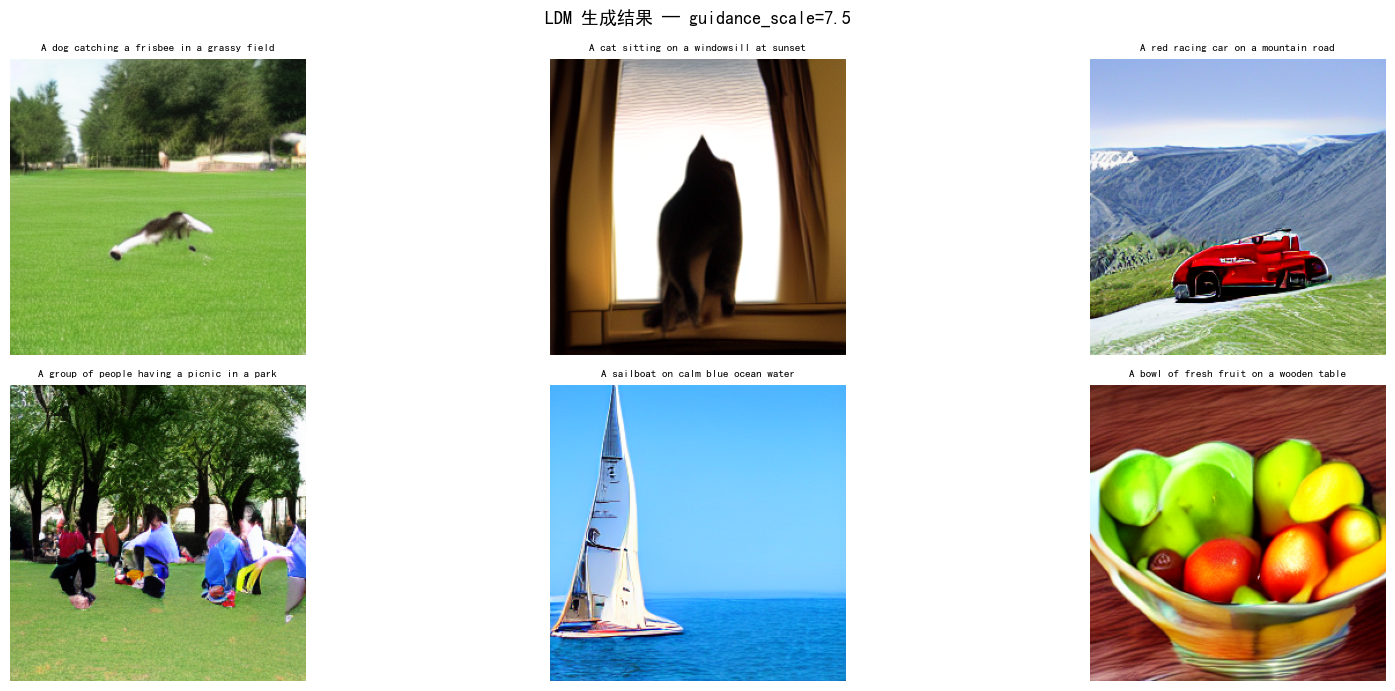

图像已保存至 ldm_generated_samples.png


In [ ]:
#  生成示例图像并展示

test_prompts = [
    "A dog catching a frisbee in a grassy field",
    "A cat sitting on a windowsill at sunset",
    "A red racing car on a mountain road",
    "A group of people having a picnic in a park",
    "A sailboat on calm blue ocean water",
    "A bowl of fresh fruit on a wooden table",
]

print(f"生成 {len(test_prompts)} 张图像（guidance_scale={GUIDANCE_SCALE}）...")
generated_images = generate_images(test_prompts, guidance_scale=GUIDANCE_SCALE, seed=42)

# 展示生成结果
n = len(generated_images)
fig, axes = plt.subplots(2, n // 2, figsize=(18, 7))
axes = axes.flatten()

for i, (ax, prompt, img) in enumerate(zip(axes, test_prompts, generated_images)):
    ax.imshow(img)
    ax.set_title(prompt, fontsize=8, wrap=True)
    ax.axis('off')

plt.suptitle(f'LDM 生成结果 — guidance_scale={GUIDANCE_SCALE}', fontsize=13)
plt.tight_layout()
plt.savefig('ldm_generated_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("图像已保存至 ldm_generated_samples.png")

Prompt: A dog catching a frisbee in a grassy field
CFG=7.5, Steps=50, Seed=0


图像已保存至 my_output.png


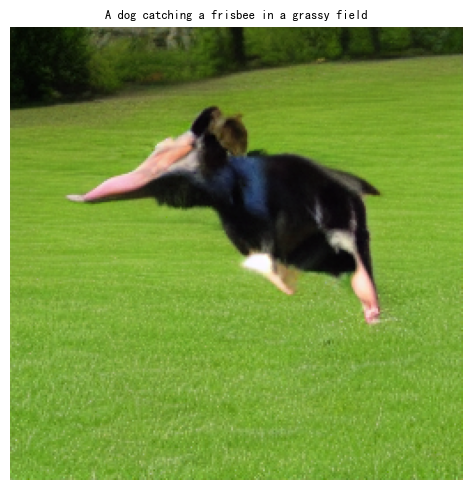

In [ ]:
#  交互式推理：自定义 Prompt

def interactive_generate(
    prompt: str,
    guidance_scale: float = 7.5,
    num_steps: int = 50,
    seed: int = 42,
    save_path: str = None
):
    """
    单条 Prompt 推理，支持调整 CFG 引导强度和推理步数。
    
    Args:
        prompt: 描述图像的英文文本
        guidance_scale: CFG 强度，推荐 5~15；越大越贴合文本
        num_steps: DDIM 步数，推荐 30~100；越多越精细但越慢
        seed: 随机种子，固定种子可复现结果
        save_path: 可选保存路径（如 'output.png'）
    """
    print(f"Prompt: {prompt}")
    print(f"CFG={guidance_scale}, Steps={num_steps}, Seed={seed}")

    imgs = generate_images([prompt], guidance_scale=guidance_scale,
                           num_inference_steps=num_steps, seed=seed)
    img = imgs[0]

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img)
    ax.set_title(prompt, fontsize=9, wrap=True)
    ax.axis('off')
    plt.tight_layout()

    if save_path:
        img.save(save_path)
        print(f"图像已保存至 {save_path}")

    plt.show()
    return img


# 示例调用
_ = interactive_generate(
    prompt       = "A dog catching a frisbee in a grassy field",
    guidance_scale = 7.5,
    num_steps    = 50,
    seed         = 0,
    save_path    = 'my_output.png'
)

Prompt: A dog catching a frisbee in a grassy field
测试 guidance_scale: [1.0, 3.0, 5.0, 7.5, 10.0, 15.0]


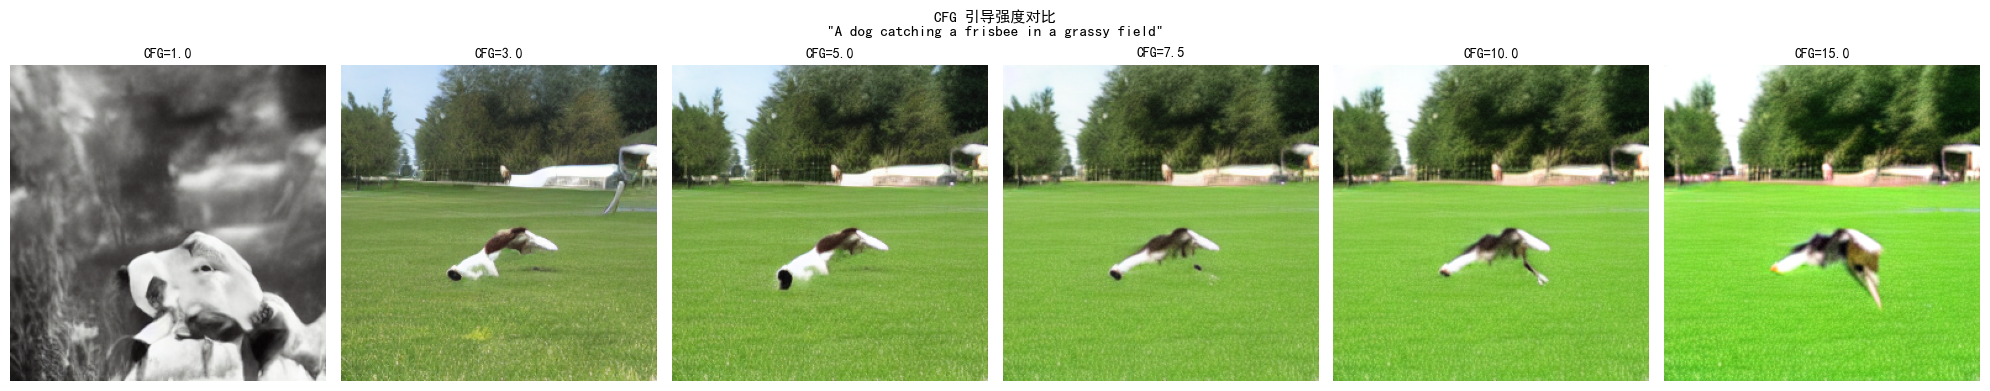

CFG 对比图已保存至 cfg_comparison.png


In [ ]:
#  CFG 引导强度对比实验
#  展示不同 guidance_scale 下同一 prompt 的生成结果差异

guidance_scales = [1.0, 3.0, 5.0, 7.5, 10.0, 15.0]
compare_prompt  = "A dog catching a frisbee in a grassy field"

print(f"Prompt: {compare_prompt}")
print(f"测试 guidance_scale: {guidance_scales}")

fig, axes = plt.subplots(1, len(guidance_scales), figsize=(20, 4))

for ax, gs in zip(axes, guidance_scales):
    imgs = generate_images([compare_prompt], guidance_scale=gs, seed=42)
    ax.imshow(imgs[0])
    ax.set_title(f'CFG={gs}', fontsize=10)
    ax.axis('off')

plt.suptitle(f'CFG 引导强度对比\n"{compare_prompt}"', fontsize=11)
plt.tight_layout()
plt.savefig('cfg_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("CFG 对比图已保存至 cfg_comparison.png")

共 4928 条训练记录


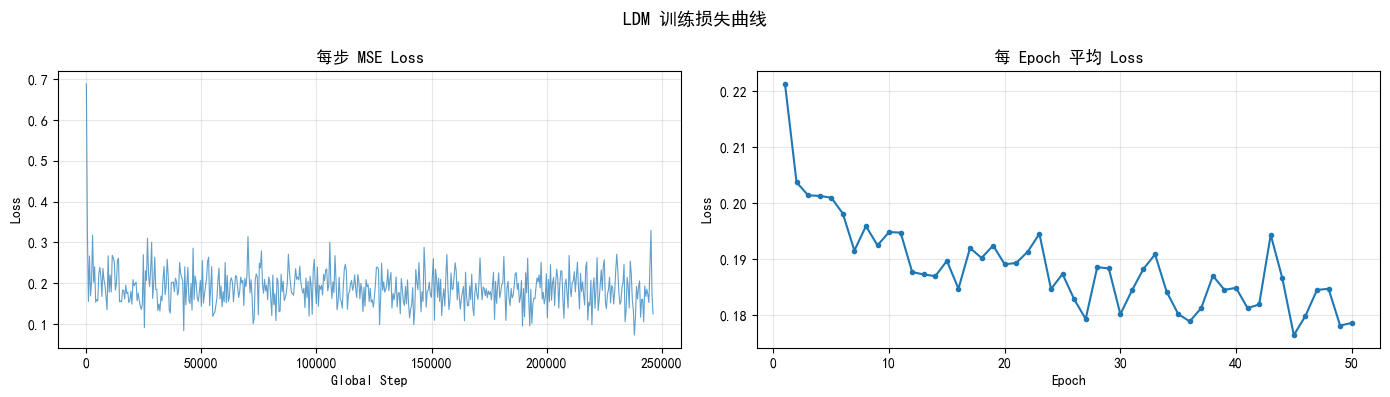

损失曲线已保存至 ldm_loss_curves.png


In [ ]:
#  训练损失曲线可视化

import pandas as pd

if os.path.exists(log_csv_path):
    df = pd.read_csv(log_csv_path)
    print(f"共 {len(df)} 条训练记录")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # 每步 Loss（采样以避免点过密）
    step_sample = max(1, len(df) // 500)
    axes[0].plot(df['global_step'].iloc[::step_sample],
                 df['loss'].iloc[::step_sample], alpha=0.7, linewidth=0.8)
    axes[0].set_title('每步 MSE Loss')
    axes[0].set_xlabel('Global Step')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)

    # 每 Epoch 平均 Loss
    epoch_avg = df.groupby('epoch')['loss'].mean()
    axes[1].plot(epoch_avg.index, epoch_avg.values, marker='o', markersize=3)
    axes[1].set_title('每 Epoch 平均 Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('LDM 训练损失曲线', fontsize=13)
    plt.tight_layout()
    plt.savefig('ldm_loss_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("损失曲线已保存至 ldm_loss_curves.png")
else:
    print(f"未找到日志文件 {log_csv_path}，请先完成训练")